**PREDIKSI HARGA EMAS HARIAN MENGGUNAKAN METODE ARIMA, LSTM, dan RNN BERBASIS TIME SERIES**

Dataset : https://www.kaggle.com/datasets/nisargchodavadiya/daily-gold-price-20152021-time-series

Anggota Kelompok 10 2024 E :
1. Aida Zahira (24031554106)
2. Luthfiana Syakira Eka Ramadani (24031554071)
3. Sabrina Miftakhul Jana (24031554148)

# Import Library

In [ ]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.2 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os

#set seed agar hasil konsisten
SEED = 50
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

#normalisasi
from sklearn.preprocessing import MinMaxScaler

#visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#statistik
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#model
from pmdarima.arima import auto_arima
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#set tampilan
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
import kagglehub
import os
path = kagglehub.dataset_download("nisargchodavadiya/daily-gold-price-20152021-time-series")

100%|██████████| 52.4k/52.4k [00:00<00:00, 10.2MB/s]

Extracting files...


In [ ]:
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

In [ ]:
print(f'Jumlah baris: {df.shape[0]} | Jumlah kolom: {df.shape[1]}')
df.head()

Jumlah baris: 3104 | Jumlah kolom: 7


,Date,Price,Open,High,Low,Volume,Chg%
0,2026-01-02,135793,136143,137037,135525,51877,0.02
1,2026-01-01,135771,135687,135850,135001,14622,0.23
2,2025-12-31,135454,136526,136527,134866,59050,1.10
3,2025-12-30,133974,133185,134880,132853,36733,1.04
4,2025-12-29,132595,137628,138269,131695,90640,-3.77


In [ ]:
df.columns.tolist()

['Date', 'Price', 'Open', 'High', 'Low', 'Volume', 'Chg%']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3104 entries, 0 to 3103
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3104 non-null   object 
 1   Price   3104 non-null   int64  
 2   Open    3104 non-null   int64  
 3   High    3104 non-null   int64  
 4   Low     3104 non-null   int64  
 5   Volume  3104 non-null   int64  
 6   Chg%    3104 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 169.9+ KB


# Pre-Processing

In [ ]:
#konversi kolom Date menjadi tipe datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

In [ ]:
#drop kolom Chg%
df.drop(columns=['Chg%'], inplace=True)

print(df.index.min().date(), '-', df.index.max().date())
print(len(df))
df.head(3)

2014-01-01 - 2026-01-02
3104


,Price,Open,High,Low,Volume
Date,,,,,
2014-01-01,29542,29435,29598,29340,2930
2014-01-02,29975,29678,30050,29678,3140
2014-01-03,29727,30031,30125,29539,3050


In [ ]:
#statistik deskriptif
df.describe().round(2)

,Price,Open,High,Low,Volume
count,3104.00,3104.00,3104.00,3104.00,3104.00
mean,46263.72,46250.18,46515.67,45997.23,14855.16
std,22230.39,22191.26,22364.94,22053.60,14197.12
min,24545.00,24583.00,24635.00,24470.00,0.00
25%,29358.75,29331.50,29462.75,29214.00,6780.00
50%,38832.50,38902.50,39083.00,38626.50,11520.00
75%,54970.25,54900.00,55211.25,54730.50,18602.50
max,137789.00,137628.00,138300.00,136300.00,149474.00


In [ ]:
#cek missing value
missing = df.isnull().sum()
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': (missing / len(df) * 100).round(2)
})

print(missing_df)

if missing.sum() != 0:
    print(f'Total missing value: {missing.sum()}')

        Jumlah Missing  Persentase (%)
Price                0             0.0
Open                 0             0.0
High                 0             0.0
Low                  0             0.0
Volume               0             0.0


In [ ]:
#cek duplikat
duplikat = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplikat}')

if duplikat != 0:
    print(f'Ditemukan {duplikat} duplikat, data akan dihapus')
    df = df.drop_duplicates()

Jumlah data duplikat: 1
Ditemukan 1 duplikat, data akan dihapus


In [ ]:
#cek outlier dengan IQR
kolom_numerik = ['Open', 'High', 'Low', 'Price', 'Volume']

for col in kolom_numerik:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        print(f'{col}: IQR={IQR:.2f}, lower={lower:.2f}, upper={upper:.2f}, outlier={outliers}')

Open: IQR=25568.00, lower=-9020.00, upper=93252.00, outlier=179
High: IQR=25809.50, lower=-9251.25, upper=93986.75, outlier=179
Low: IQR=25544.50, lower=-9101.25, upper=93076.75, outlier=174
Price: IQR=25625.00, lower=-9077.00, upper=93423.00, outlier=177
Volume: IQR=11810.00, lower=-10920.00, upper=36320.00, outlier=228


In [ ]:
#uji stasioner ADF
for col in kolom_numerik:
    if col in df:
        _, p, *_ = adfuller(df[col].dropna())
        print(f'{col}: p={p:.4f}, {"stasioner" if p < 0.05 else "tidak stasioner"}')

Open: p=1.0000, tidak stasioner
High: p=1.0000, tidak stasioner
Low: p=1.0000, tidak stasioner
Price: p=1.0000, tidak stasioner
Volume: p=0.0952, tidak stasioner


In [ ]:
#differencing untuk buat data stasioner (untuk ARIMA)
df['Price_diff'] = df['Price'].diff()

_, p, *_ = adfuller(df['Price_diff'].dropna())
print(f'p={p:.6f}, {"stasioner" if p < 0.05 else "tidak"}')

p=0.000000, stasioner


In [ ]:
#normalisasi untuk LSTM
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Price', 'Open', 'High', 'Low', 'Volume']])

#scaler khusus untuk price saja
scaler_price = MinMaxScaler()
price_scaled = scaler_price.fit_transform(df[['Price']])

# EDA

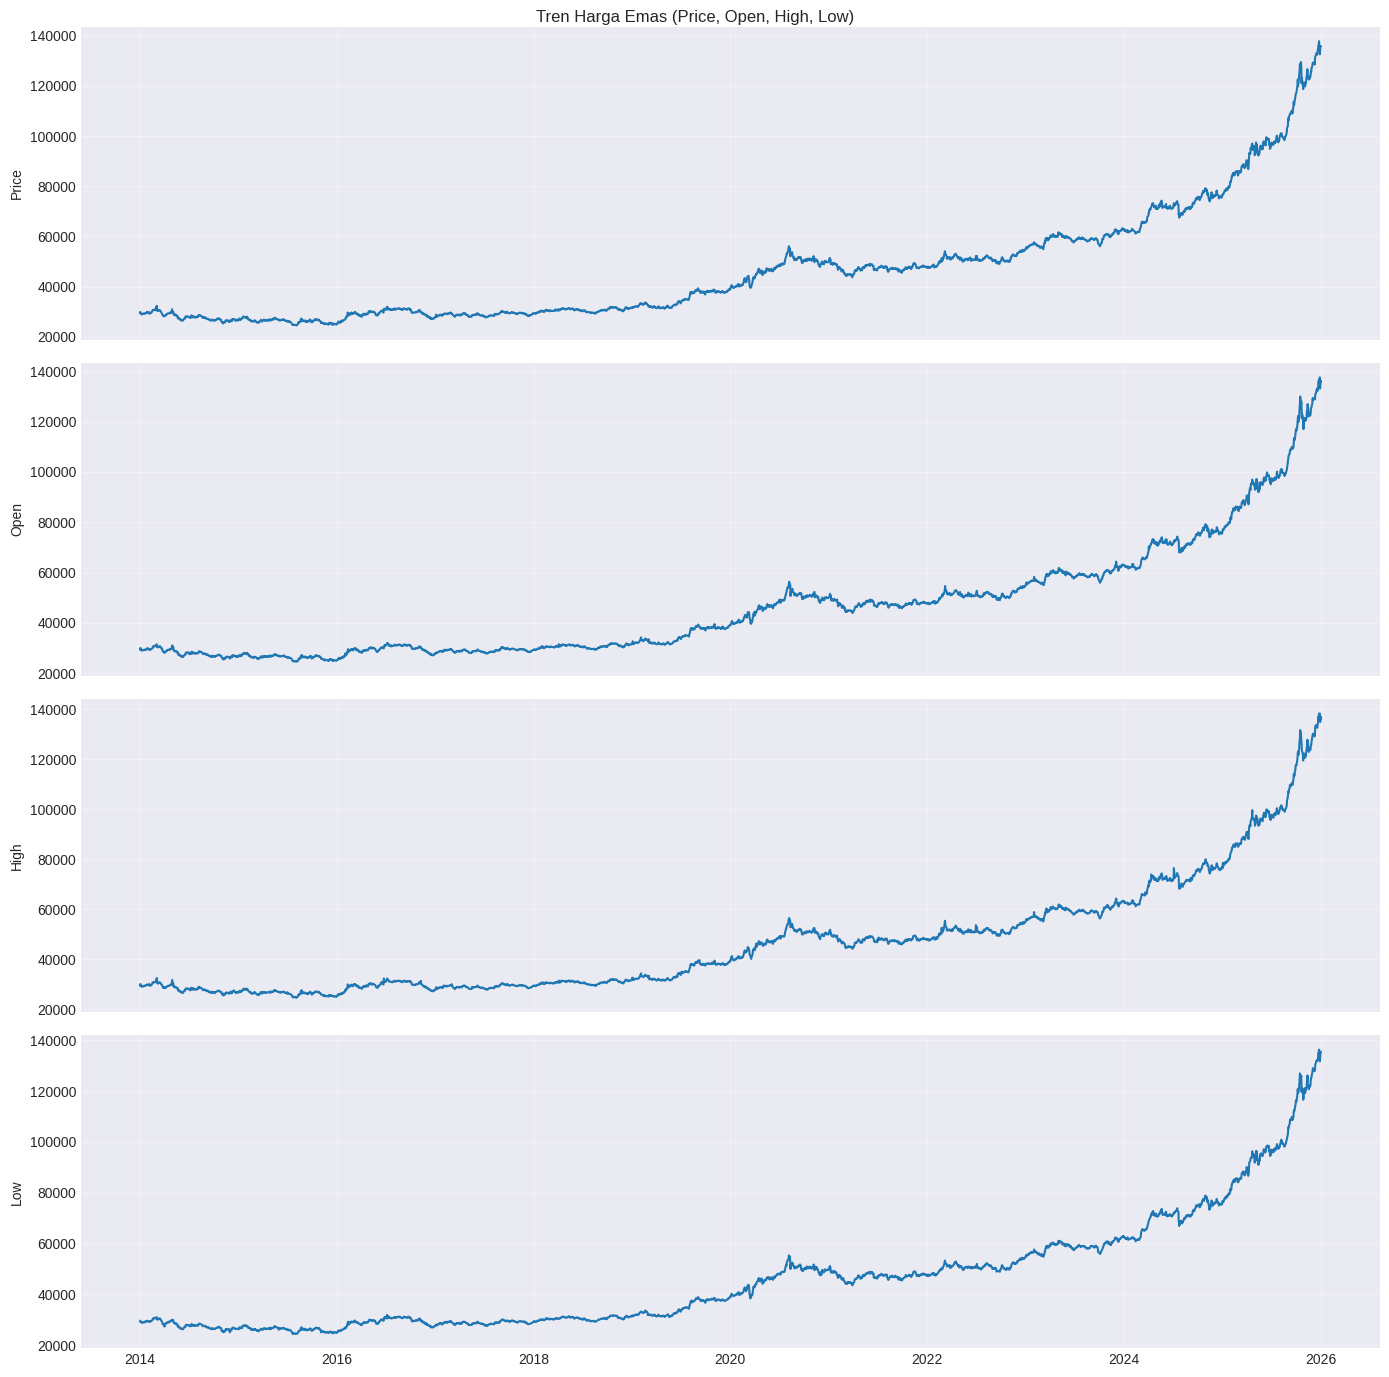

In [ ]:
# tren harga emas
kolom = [c for c in ['Price', 'Open', 'High', 'Low'] if c in df]

fig, axes = plt.subplots(len(kolom), 1, figsize=(14, 3.5*len(kolom)), sharex=True)
axes = [axes] if len(kolom) == 1 else axes

for ax, col in zip(axes, kolom):
    ax.plot(df.index, df[col])
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Tren Harga Emas (Price, Open, High, Low)')
plt.tight_layout()
plt.show()

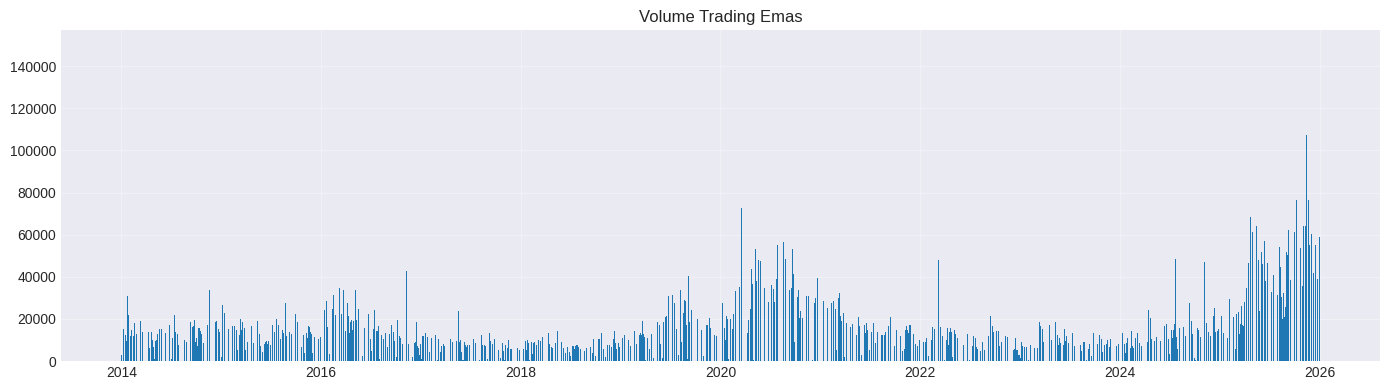

In [ ]:
#volume trading
if 'Volume' in df:
    plt.figure(figsize=(14, 4))
    plt.bar(df.index, df['Volume'])
    plt.title('Volume Trading Emas')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

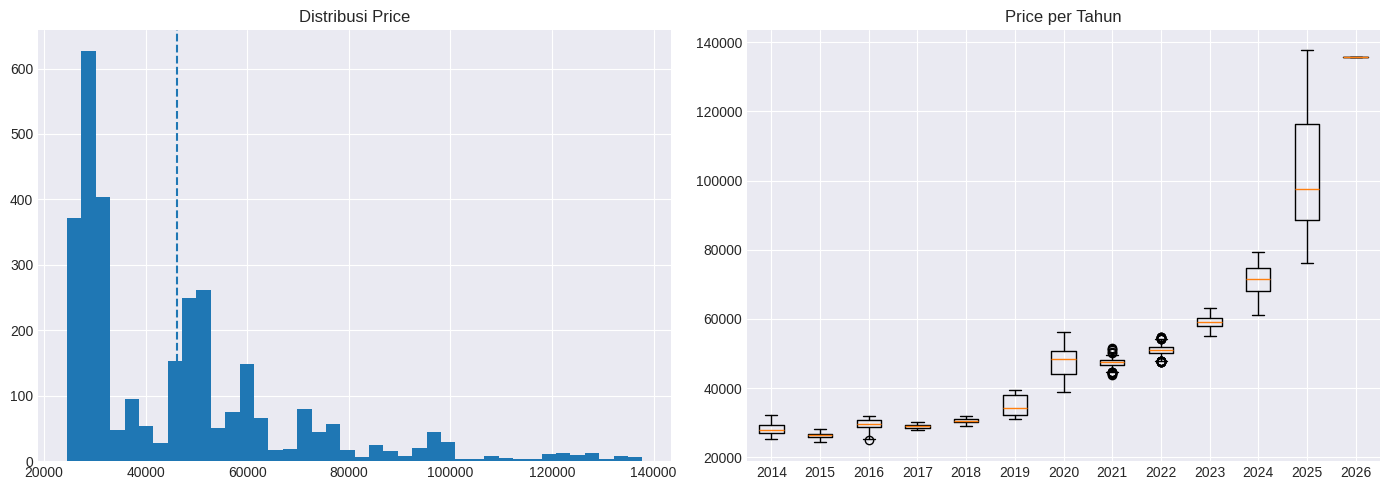

In [ ]:
#distribusi & boxplot per tahun
col = 'Price'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#histogram
axes[0].hist(df[col], bins=40)
axes[0].axvline(df[col].mean(), linestyle='--')
axes[0].set_title(f'Distribusi {col}')

#boxplot per tahun
df_plot = df.copy()
df_plot['Year'] = df_plot.index.year
years = sorted(df_plot['Year'].unique())
data = [df_plot[df_plot['Year'] == y][col] for y in years]

axes[1].boxplot(data, labels=years)
axes[1].set_title(f'{col} per Tahun')

plt.tight_layout()
plt.show()

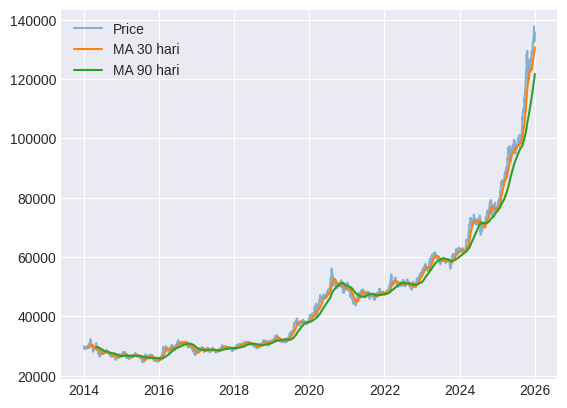

In [ ]:
#moving average
df['MA_30'] = df['Price'].rolling(window=30).mean()
df['MA_90'] = df['Price'].rolling(window=90).mean()
plt.plot(df['Price'], label='Price', alpha=0.5)
plt.plot(df['MA_30'], label='MA 30 hari')
plt.plot(df['MA_90'], label='MA 90 hari')
plt.legend()
plt.show()

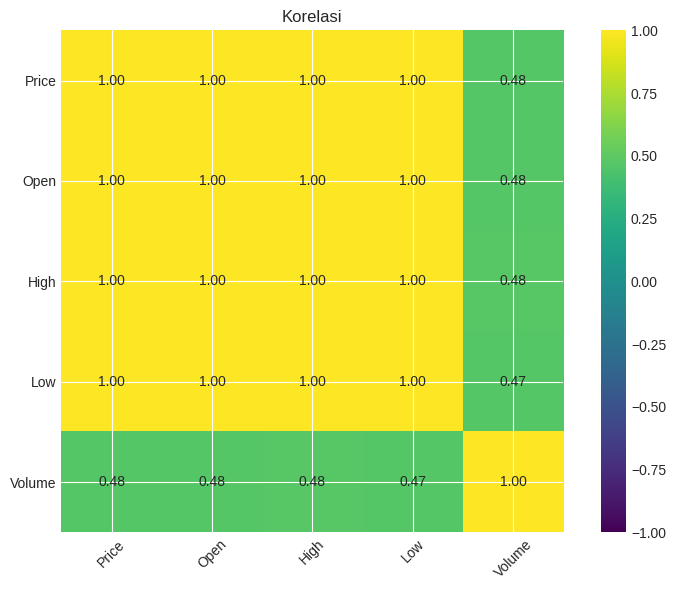

In [ ]:
#korelasi antar fitur
kolom = [c for c in ['Price', 'Open', 'High', 'Low', 'Volume'] if c in df]
corr = df[kolom].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='viridis', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(kolom)), kolom, rotation=45)
plt.yticks(range(len(kolom)), kolom)

for i in range(len(kolom)):
    for j in range(len(kolom)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')

plt.title('Korelasi')
plt.tight_layout()
plt.show()

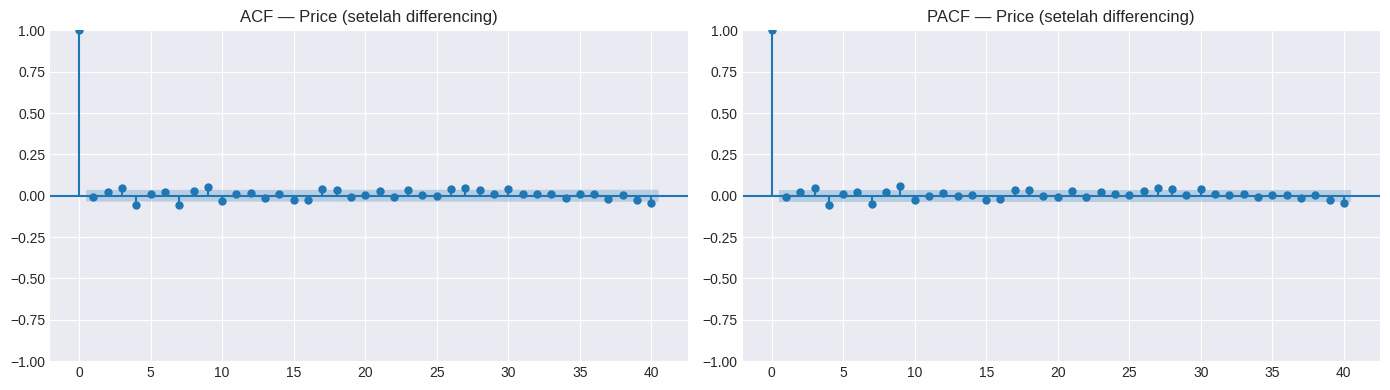

In [ ]:
#ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['Price_diff'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['Price_diff'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('ACF — Price (setelah differencing)')
axes[1].set_title('PACF — Price (setelah differencing)')
plt.tight_layout()
plt.show()

# Split data

- Train = 2014 - 2024
- Test = 2025
- Periode COVID (2020-2021) dimasukkan ke data train agar model belajar dari lonjakan harga ekstrem, sehingga lebih robust saat memprediksi kondisi yang tidak biasa

In [ ]:
# split berbasis tanggal
train_price = df.loc[:'2024-12-31', 'Price']
test_price  = df.loc['2025-01-01':, 'Price']

print(f'Total data  : {len(df)}')
print(f'Data train  : {len(train_price)} ({train_price.index.min().date()} – {train_price.index.max().date()})')
print(f'Data test   : {len(test_price)} ({test_price.index.min().date()} – {test_price.index.max().date()})')

Total data  : 3103
Data train  : 2843 (2014-01-01 – 2024-12-31)
Data test   : 260 (2025-01-01 – 2026-01-02)


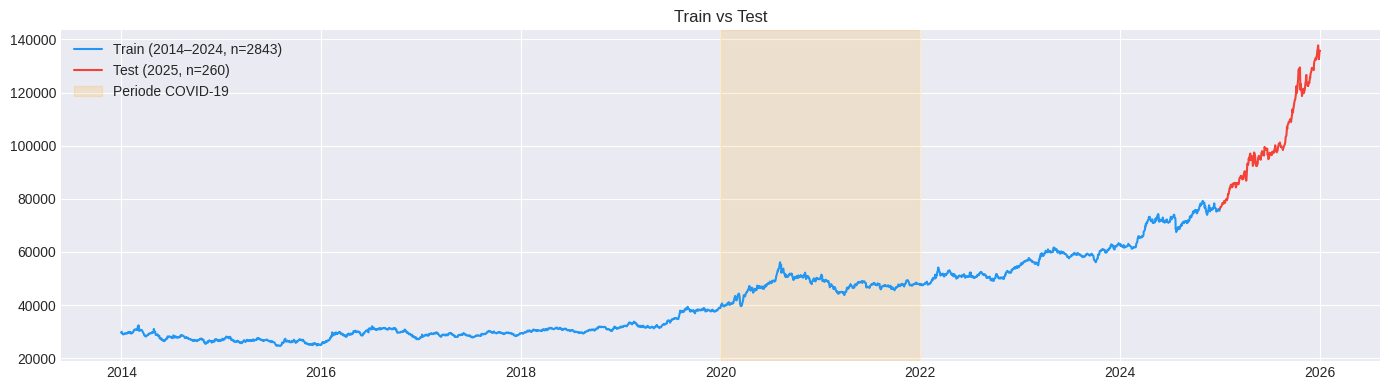

In [ ]:
#visualisasi split
plt.figure(figsize=(14, 4))
plt.plot(train_price, label=f'Train (2014–2024, n={len(train_price)})', color='#2196F3')
plt.plot(test_price,  label=f'Test (2025, n={len(test_price)})', color='#F44336')

#periode covid
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'),
            alpha=0.15, color='orange', label='Periode COVID-19')


plt.title('Train vs Test')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# ARIMA

In [ ]:
# model arima
model_arima = auto_arima(
    train_price,
    seasonal=False,
    stepwise=True,
    information_criterion='aic',
    suppress_warnings=True
)

print(f'\n Parameter terbaik: {model_arima.order}')
print(model_arima.summary())


 Parameter terbaik: (0, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2843
Model:               SARIMAX(0, 1, 2)   Log Likelihood              -20763.845
Date:                Sat, 16 May 2026   AIC                          41535.690
Time:                        11:35:55   BIC                          41559.499
Sample:                             0   HQIC                         41544.277
                               - 2843                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     16.1737      7.375      2.193      0.028       1.719      30.629
ma.L1         -0.0261      0.015     -1.783      0.075      -0.055       0.003
ma.L2          0.0583

In [ ]:
#prediksi arima
pred_arima = model_arima.predict(n_periods=len(test_price))

#konversi ke array numpy
actual_arima = test_price.values
pred_arima   = np.array(pred_arima)

In [ ]:
# evaluasi arima
mae_arima  = mean_absolute_error(actual_arima, pred_arima)
rmse_arima = np.sqrt(mean_squared_error(actual_arima, pred_arima))
mape_arima = np.mean(np.abs((actual_arima - pred_arima) / actual_arima)) * 100
r2_arima   = r2_score(actual_arima, pred_arima)

print(f'MAE  : {mae_arima:.4f}')
print(f'RMSE : {rmse_arima:.4f}')
print(f'MAPE : {mape_arima:.4f}%')
print(f'R2   : {r2_arima:.4f}')

MAE  : 23614.8440
RMSE : 28103.9710
MAPE : 21.4247%
R2   : -1.9359


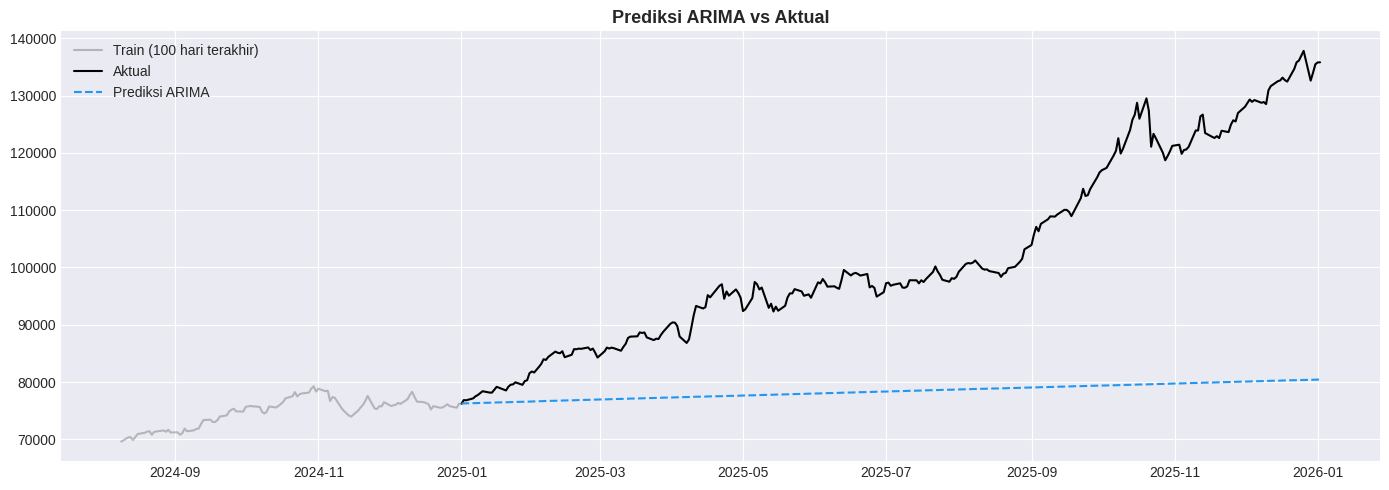

In [ ]:
#visualisasi prediksi arima
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_price.index[-100:], train_price[-100:],
        label='Train (100 hari terakhir)', color='gray', alpha=0.5)
ax.plot(test_price.index, actual_arima,
        label='Aktual', color='black')
ax.plot(test_price.index, pred_arima,
        label='Prediksi ARIMA', color='#2196F3', linestyle='--')
ax.set_title('Prediksi ARIMA vs Aktual', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Data untuk Deep Learning ( LSTM & RNN)

In [ ]:
WINDOW = 60

# function untuk membuat sequence
def create_sequences(data, window):
    X, y = [], []

    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [ ]:
#membuat sequence dari seluruh data
X_all, y_all = create_sequences(price_scaled, WINDOW)

In [ ]:
#menentukan split train dan test
n_train = len(train_price)
split_idx = n_train - WINDOW

X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

In [ ]:
#reshape data untuk input LSTM
X_train = X_train.reshape(*X_train.shape, 1)
X_test  = X_test.reshape(*X_test.shape, 1)

#shape data
print(f'X_train : {X_train.shape}')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')

X_train : (2783, 60, 1)
y_train : (2783,)
X_test  : (260, 60, 1)
y_test  : (260,)


# LSTM

In [ ]:
#model LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training lstm
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0013 - val_loss: 1.6412e-04
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 3.2914e-04 - val_loss: 3.9633e-04
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 2.8909e-04 - val_loss: 2.8950e-04
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 2.6330e-04 - val_loss: 1.3638e-04
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 2.4736e-04 - val_loss: 4.6732e-04
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 2.2454e-04 - val_loss: 3.3250e-04
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 2.4124e-04 - val_loss: 2.1464e-04
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 2.0040e-04 - val_loss: 1.3621e-04
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 2.0987e-04 - val_loss: 2.2606e-04
Epoch 10/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 1.8192e-04 - val_loss: 1.3235e-04
Epoch 11/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 1.

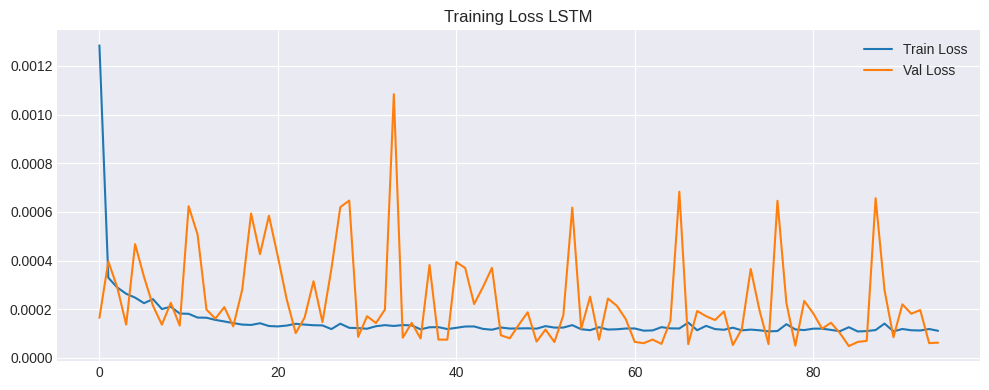

In [ ]:
#plot loss training
plt.figure(figsize=(10, 4))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('Training Loss LSTM')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#prediksi LSTM & inverse transform
pred_lstm   = scaler_price.inverse_transform(model_lstm.predict(X_test)).flatten()
actual_dl   = scaler_price.inverse_transform(y_test.reshape(-1, 1)).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [ ]:
#evaluasi LSTM
mae_lstm  = mean_absolute_error(actual_dl, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(actual_dl, pred_lstm))
mape_lstm = np.mean(np.abs((actual_dl - pred_lstm) / actual_dl)) * 100
r2_lstm   = r2_score(actual_dl, pred_lstm)

print(f'MAE  : {mae_lstm:.4f}')
print(f'RMSE : {rmse_lstm:.4f}')
print(f'MAPE : {mape_lstm:.4f}%')
print(f'R2   : {r2_lstm:.4f}')

MAE  : 2603.6550
RMSE : 3395.0640
MAPE : 2.3462%
R2   : 0.9572


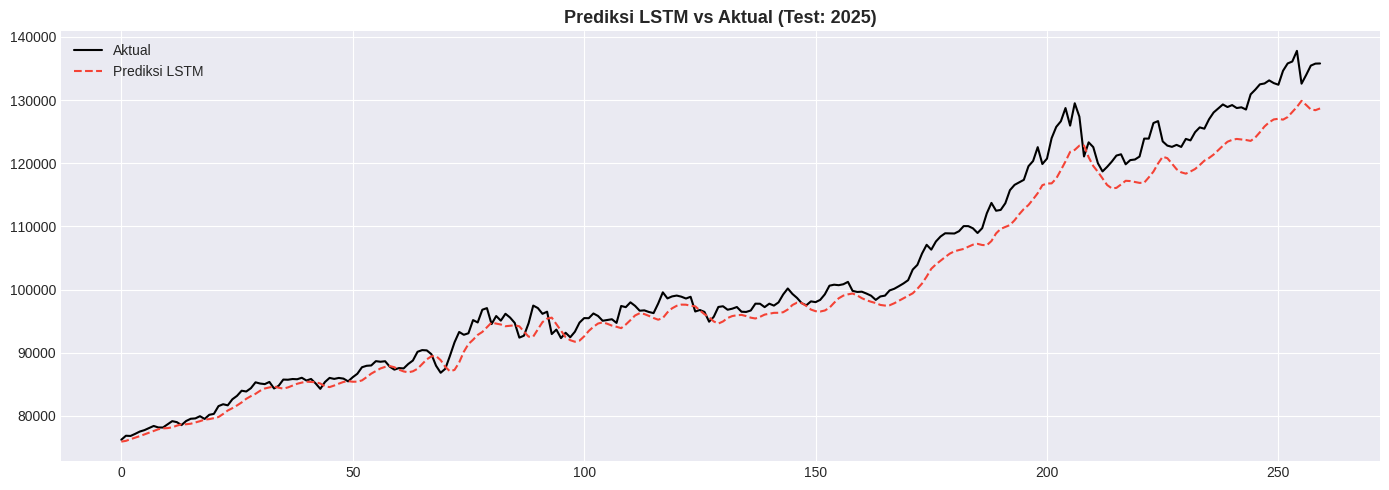

In [ ]:
#visualisasi prediksi LSTM
plt.figure(figsize=(14, 5))
plt.plot(actual_dl, label='Aktual', color='black')
plt.plot(pred_lstm, label='Prediksi LSTM', color='#F44336', linestyle='--')
plt.title('Prediksi LSTM vs Aktual (Test: 2025)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# RNN (Recurrent Neural Network)

In [ ]:
#model RNN
model_rnn = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    SimpleRNN(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#training RNN
early_stop_rnn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop_rnn],
    verbose=1
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0193 - val_loss: 0.0027
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0038 - val_loss: 0.0011
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0023 - val_loss: 0.0051
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0014 - val_loss: 4.2573e-04
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0011 - val_loss: 7.5706e-04
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 9.9283e-04 - val_loss: 8.3790e-04
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 8.3324e-04 - val_loss: 0.0012
Epoch 9/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 8.0336e-04 - val_loss: 9.7039e-04
Epoch 10/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 7.0571e-04 - val_loss: 6.8573e-04
Epoch 11/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 6.5049e-04 - val_loss: 5.8815e-04
Epoch 12

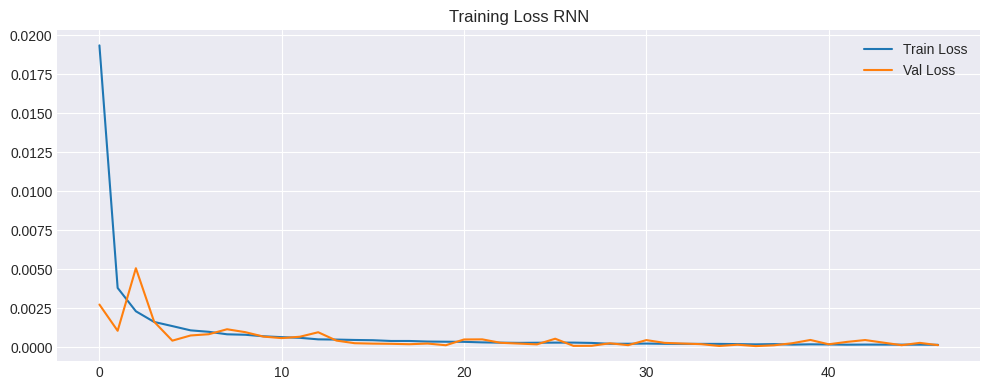

In [ ]:
#plot loss training
plt.figure(figsize=(10, 4))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('Training Loss RNN')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# prediksi RNN
pred_rnn  = scaler_price.inverse_transform(model_rnn.predict(X_test)).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [ ]:
#evaluasi RNN
mae_rnn  = mean_absolute_error(actual_dl, pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(actual_dl, pred_rnn))
mape_rnn = np.mean(np.abs((actual_dl - pred_rnn) / actual_dl)) * 100
r2_rnn   = r2_score(actual_dl, pred_rnn)

print(f'MAE  : {mae_rnn:.4f}')
print(f'RMSE : {rmse_rnn:.4f}')
print(f'MAPE : {mape_rnn:.4f}%')
print(f'R2   : {r2_rnn:.4f}')

MAE  : 4720.5486
RMSE : 5761.2668
MAPE : 4.2975%
R2   : 0.8766


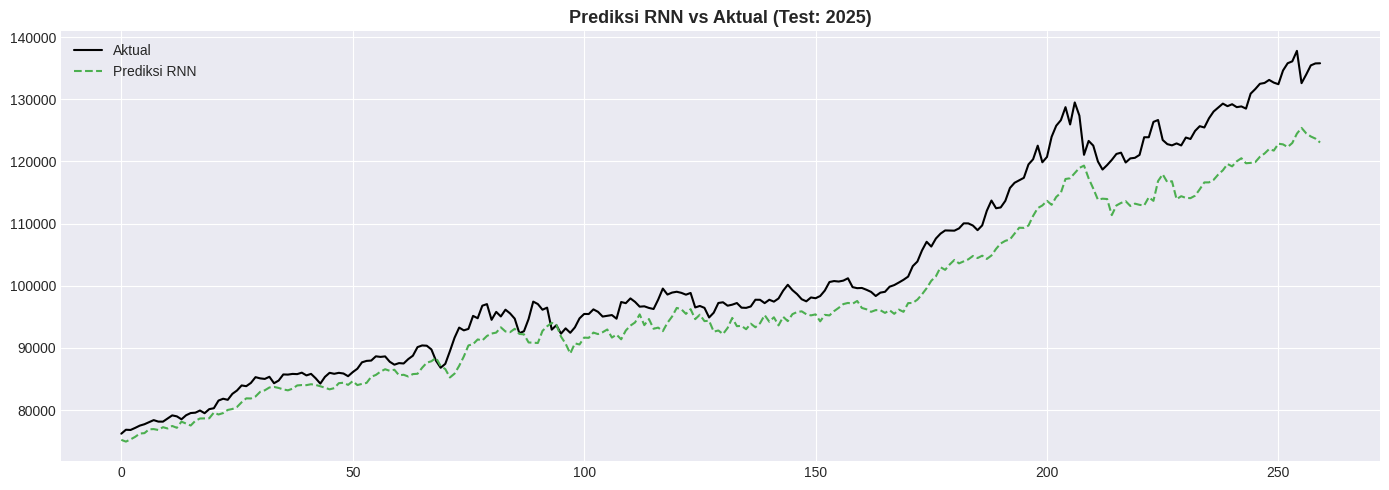

In [ ]:
#visualisasi prediksi RNN
plt.figure(figsize=(14, 5))
plt.plot(actual_dl, label='Aktual', color='black')
plt.plot(pred_rnn, label='Prediksi RNN', color='#4CAF50', linestyle='--')
plt.title('Prediksi RNN vs Aktual (Test: 2025)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Perbandingan

In [ ]:
#tabel perbandingan metrik
hasil = pd.DataFrame({
    'Model'   : ['ARIMA', 'LSTM', 'RNN'],
    'MAE'     : [round(mae_arima, 4),  round(mae_lstm, 4),  round(mae_rnn, 4)],
    'RMSE'    : [round(rmse_arima, 4), round(rmse_lstm, 4), round(rmse_rnn, 4)],
    'MAPE (%)': [round(mape_arima, 4), round(mape_lstm, 4), round(mape_rnn, 4)],
    'R2'      : [round(r2_arima, 4),   round(r2_lstm, 4),   round(r2_rnn, 4)]
})

print(hasil)

model_terbaik = hasil.loc[hasil['MAPE (%)'].idxmin(), 'Model']
print(f'\n Model terbaik berdasarkan MAPE: {model_terbaik}')

   Model         MAE        RMSE  MAPE (%)      R2
0  ARIMA  23614.8440  28103.9710   21.4247 -1.9359
1   LSTM   2603.6550   3395.0640    2.3462  0.9572
2    RNN   4720.5486   5761.2668    4.2975  0.8766

 Model terbaik berdasarkan MAPE: LSTM


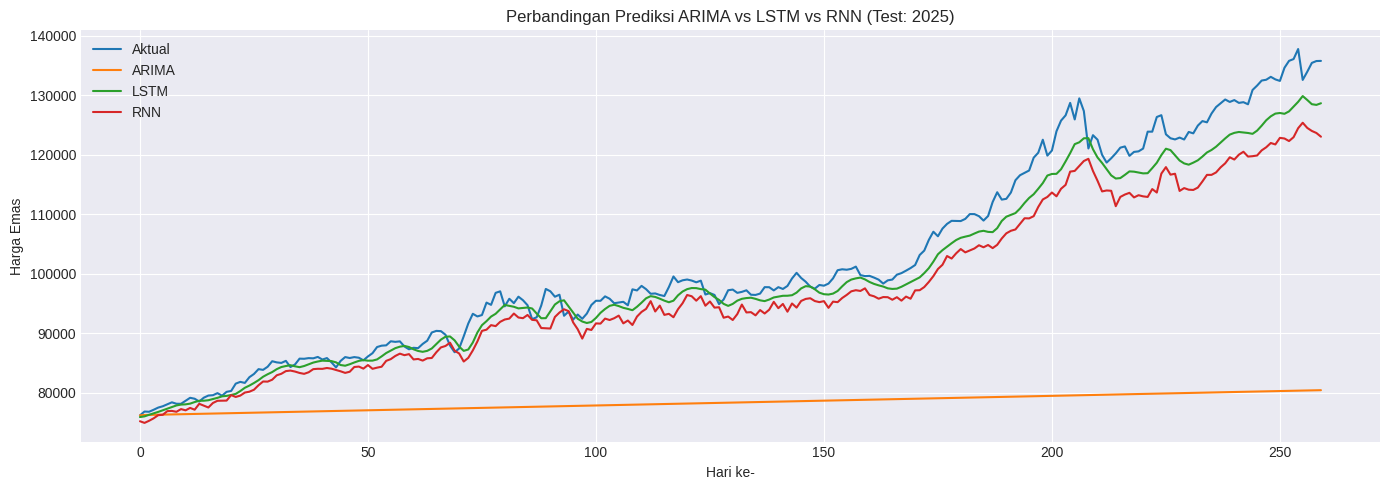

Best: LSTM


In [ ]:
#visualisasi perbandingan
n = min(len(pred_arima), len(pred_lstm), len(pred_rnn))

plt.figure(figsize=(14, 5))
plt.plot(actual_dl[:n],    label='Aktual')
plt.plot(pred_arima[:n],   label='ARIMA')
plt.plot(pred_lstm[:n],    label='LSTM')
plt.plot(pred_rnn[:n],     label='RNN')


plt.title('Perbandingan Prediksi ARIMA vs LSTM vs RNN (Test: 2025)')
plt.xlabel('Hari ke-')
plt.ylabel('Harga Emas')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best: {model_terbaik}')

# Forecasting 60 hari ke depan

In [ ]:
FORECAST_DAYS = 60

last_date = df.index[-1]
future_dates = pd.bdate_range(
    start=last_date + pd.Timedelta(days=1),
    periods=FORECAST_DAYS
)

print(f'Tanggal terakhir : {last_date.date()}')
print(f'Forecast sampai  : {future_dates[-1].date()}')

Tanggal terakhir : 2026-01-02
Forecast sampai  : 2026-03-27


In [ ]:
#forecasting arima
fc_arima = np.array(model_arima.predict(n_periods=FORECAST_DAYS))

print(f'Prediksi hari ke-1  : {fc_arima[0]:,.2f}')
print(f'Prediksi hari ke-60 : {fc_arima[-1]:,.2f}')

Prediksi hari ke-1  : 76,210.82
Prediksi hari ke-60 : 77,206.47


In [ ]:
#forecasting LSTM
last_sequence_lstm = price_scaled[-WINDOW:].copy()
fc_lstm = []

for _ in range(FORECAST_DAYS):
    input_seq = tf.constant(last_sequence_lstm.reshape(1, WINDOW, 1), dtype=tf.float32)
    next_pred = float(model_lstm(input_seq, training=False)[0, 0])
    fc_lstm.append(next_pred)
    last_sequence_lstm = np.vstack([last_sequence_lstm[1:], [[next_pred]]])

fc_lstm = scaler_price.inverse_transform(
    np.array(fc_lstm).reshape(-1, 1)
).flatten()

print(f'Prediksi hari ke-1  : {fc_lstm[0]:,.2f}')
print(f'Prediksi hari ke-60 : {fc_lstm[-1]:,.2f}')

Prediksi hari ke-1  : 129,055.98
Prediksi hari ke-60 : 87,699.53


In [ ]:
#forecasting RNN
last_sequence_rnn = price_scaled[-WINDOW:].copy()
fc_rnn = []

for _ in range(FORECAST_DAYS):
    input_seq = tf.constant(last_sequence_rnn.reshape(1, WINDOW, 1), dtype=tf.float32)
    next_pred = float(model_rnn(input_seq, training=False)[0, 0])
    fc_rnn.append(next_pred)
    last_sequence_rnn = np.vstack([last_sequence_rnn[1:], [[next_pred]]])

fc_rnn = scaler_price.inverse_transform(
    np.array(fc_rnn).reshape(-1, 1)
).flatten()

print(f'Prediksi hari ke-1  : {fc_rnn[0]:,.2f}')
print(f'Prediksi hari ke-60 : {fc_rnn[-1]:,.2f}')

Prediksi hari ke-1  : 124,921.89
Prediksi hari ke-60 : 75,841.35


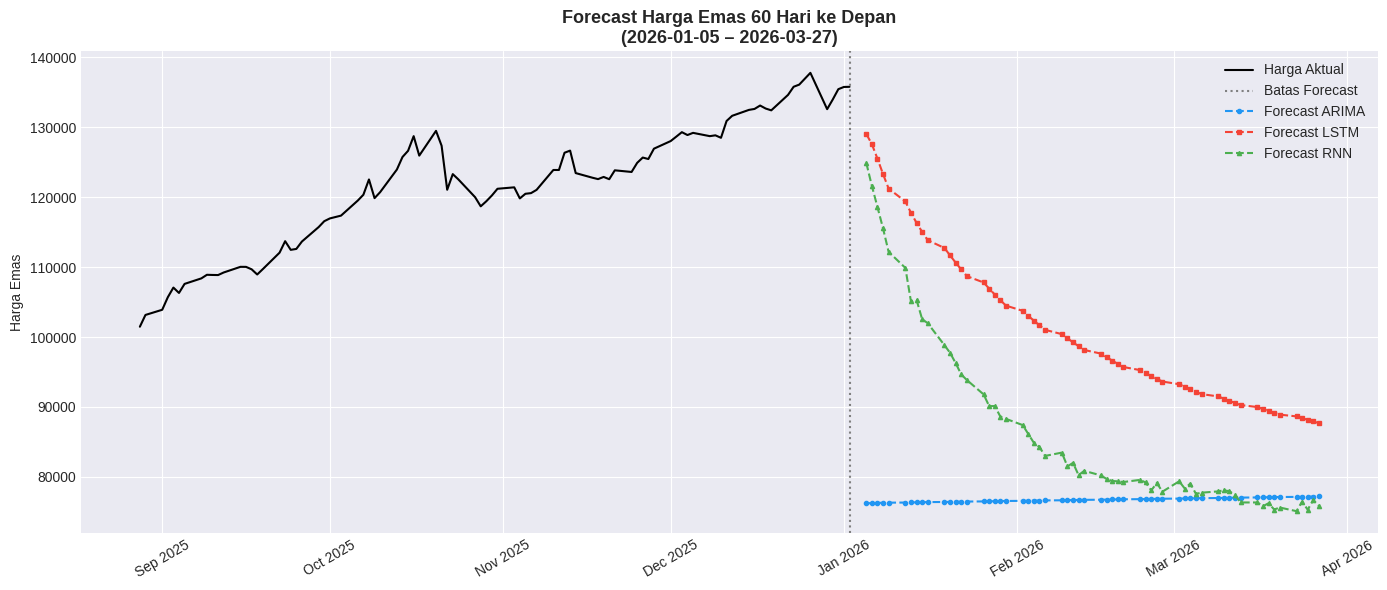

In [ ]:
#visualisasi forecasting
hist_show = df['Price'].iloc[-90:]
fig, ax = plt.subplots(figsize=(14, 6))

#data aktual
ax.plot(hist_show.index, hist_show,
        color='black', linewidth=1.5,
        label='Harga Aktual')

#batas forecast
ax.axvline(last_date, color='gray',
           linestyle=':', linewidth=1.5,
           label='Batas Forecast')

#hasil forecasting
models = {
    'ARIMA': (fc_arima, '#2196F3', 'o'),
    'LSTM' : (fc_lstm,  '#F44336', 's'),
    'RNN'  : (fc_rnn,   '#4CAF50', '^')
}

for name, (pred, color, marker) in models.items():
    ax.plot(future_dates, pred,
            linestyle='--', linewidth=1.5,
            marker=marker, markersize=3,
            color=color, label=f'Forecast {name}')
ax.set_title(
    f'Forecast Harga Emas 60 Hari ke Depan\n'
    f'({future_dates[0].date()} – {future_dates[-1].date()})',
    fontsize=13, fontweight='bold'
)

ax.set_ylabel('Harga Emas')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
#hasil forecasting
df_forecast = pd.DataFrame({
    'Hari ke-' : range(1, FORECAST_DAYS + 1),
    'Tanggal'  : future_dates,
    'ARIMA'    : fc_arima.round(2),
    'LSTM'     : fc_lstm.round(2),
    'RNN'      : fc_rnn.round(2)
})

print('=' * 65)
print('HASIL FORECASTING HARGA EMAS')
print('=' * 65)

print(df_forecast.to_string(index=False))

HASIL FORECASTING HARGA EMAS
 Hari ke-    Tanggal    ARIMA      LSTM       RNN
        1 2026-01-05 76210.82 129055.98 124921.89
        2 2026-01-06 76268.39 127596.94 121626.48
        3 2026-01-07 76284.57 125520.08 118609.05
        4 2026-01-08 76300.74 123314.64 115548.72
        5 2026-01-09 76316.91 121240.04 112186.92
        6 2026-01-12 76333.09 119390.38 109888.80
        7 2026-01-13 76349.26 117768.05 105089.50
        8 2026-01-14 76365.43 116335.08 105317.74
        9 2026-01-15 76381.61 115044.31 102557.83
       10 2026-01-16 76397.78 113854.78 101984.98
       11 2026-01-19 76413.96 112736.94  98830.10
       12 2026-01-20 76430.13 111672.15  97743.86
       13 2026-01-21 76446.30 110650.26  96266.69
       14 2026-01-22 76462.48 109666.43  94653.76
       15 2026-01-23 76478.65 108718.77  93858.45
       16 2026-01-26 76494.82 107806.58  91802.78
       17 2026-01-27 76511.00 106929.38  90121.84
       18 2026-01-28 76527.17 106086.52  90131.30
       19 2026-01-29 

In [ ]:
#ringkasan
print('\n RINGKASAN FORECASTING')

for name, fc in {
    'ARIMA': fc_arima,
    'LSTM' : fc_lstm,
    'RNN'  : fc_rnn
}.items():
    trend = 'naik' if fc[-1] > fc[0] else 'turun'

    print(
        f'{name:6s} | '
        f'Hari 1 : {fc[0]:>12,.2f} | '
        f'Hari 60 : {fc[-1]:>12,.2f} | '
        f'{trend}'
    )


 RINGKASAN FORECASTING
ARIMA  | Hari 1 :    76,210.82 | Hari 60 :    77,206.47 | naik
LSTM   | Hari 1 :   129,055.98 | Hari 60 :    87,699.53 | turun
RNN    | Hari 1 :   124,921.89 | Hari 60 :    75,841.35 | turun
